## Importing Main Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load and Explore Dataset

In [2]:
df = pd.read_csv("../data/AI-Based Hiring Prediction System data.csv")

print(df.head())

   Resume_ID              Name                                        Skills  \
0          1        Ashley Ali                      TensorFlow, NLP, Pytorch   
1          2      Wesley Roman  Deep Learning, Machine Learning, Python, SQL   
2          3     Corey Sanchez         Ethical Hacking, Cybersecurity, Linux   
3          4  Elizabeth Carney                   Python, Pytorch, TensorFlow   
4          5        Julie Hill                              SQL, React, Java   

   Experience (Years) Education                Certifications  \
0                  10      B.Sc                           NaN   
1                  10       MBA                     Google ML   
2                   1       MBA  Deep Learning Specialization   
3                   7    B.Tech                 AWS Certified   
4                   4       PhD                           NaN   

                Job Role Recruiter Decision  Salary Expectation ($)  \
0          AI Researcher               Hire              

### Ckeck information

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB
None


In [4]:
print(df.describe())

         Resume_ID  Experience (Years)  Salary Expectation ($)  \
count  1000.000000         1000.000000             1000.000000   
mean    500.500000            4.896000            79994.486000   
std     288.819436            3.112695            23048.472549   
min       1.000000            0.000000            40085.000000   
25%     250.750000            2.000000            60415.750000   
50%     500.500000            5.000000            79834.500000   
75%     750.250000            8.000000            99583.250000   
max    1000.000000           10.000000           119901.000000   

       Projects Count  AI Score (0-100)  
count      1000.00000       1000.000000  
mean          5.13300         83.950000  
std           3.23137         20.983036  
min           0.00000         15.000000  
25%           2.00000         70.000000  
50%           5.00000        100.000000  
75%           8.00000        100.000000  
max          10.00000        100.000000  


In [5]:
print(df.columns)

Index(['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education',
       'Certifications', 'Job Role', 'Recruiter Decision',
       'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)'],
      dtype='object')


## Checking Missing Values

In [6]:
print(df.isnull().sum())

Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64


## Exploratory Data Analysis (EDA)

### Hiring Distribution

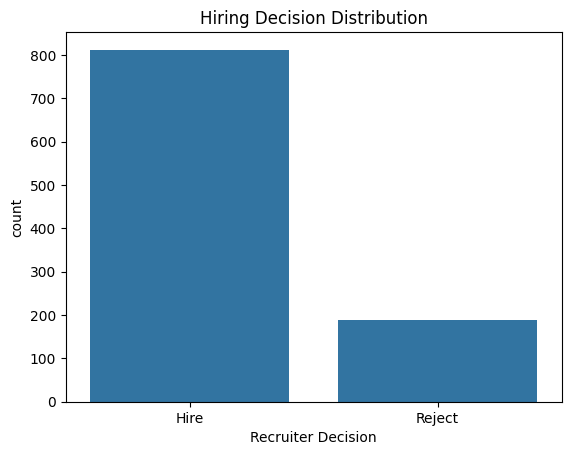

In [7]:
sns.countplot(x="Recruiter Decision",data = df)

plt.title("Hiring Decision Distribution")

plt.show()

### Experience Distribution

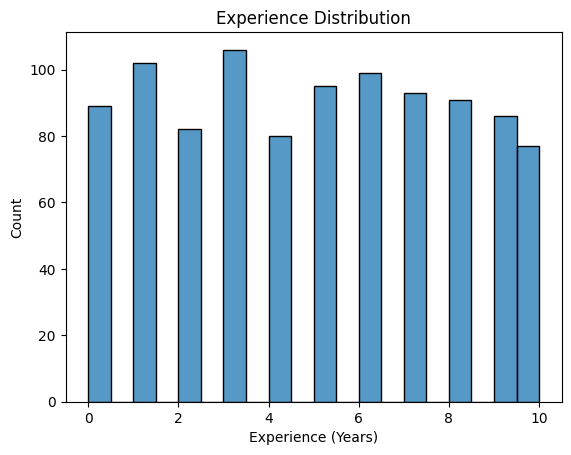

In [8]:
sns.histplot(df["Experience (Years)"],bins = 20)

plt.title("Experience Distribution")

plt.show()

### Salary Expectation Distribution

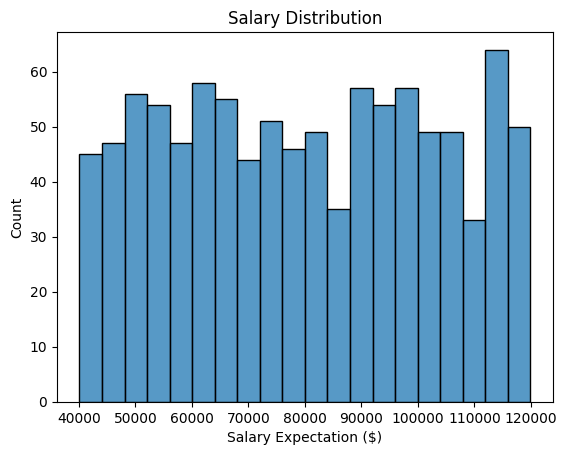

In [9]:
sns.histplot(df["Salary Expectation ($)"], bins=20)

plt.title("Salary Distribution")

plt.show()

### Education Analysis

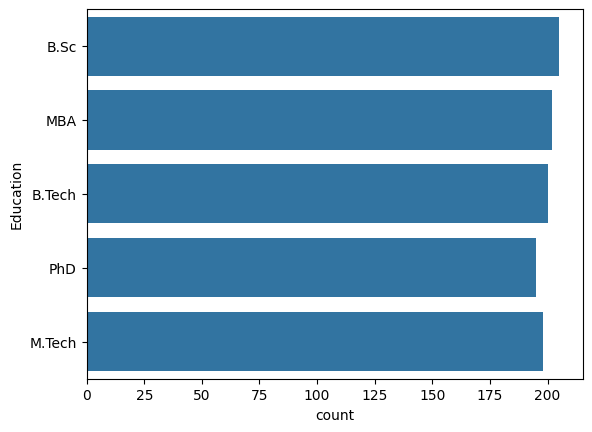

In [10]:
sns.countplot(y="Education", data = df)

plt.show()

## Data Cleaning

### Remove Unnecessary Columns

These columns don't help prediction.

In [11]:
df.drop(
    ["Resume_ID","Name"],
    axis=1,
    inplace=True
)

### Handle Missing Values

In [12]:
print(df.isnull().sum())

Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64


In [13]:
df.fillna("Unknown",inplace=True)

## Feature Engineering

dataset contains text columns like 

- Skills
- Education
- Certifications
- Job Role

Convert them into in the forms numbers

In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

In [15]:
for col in df.columns:

    if df[col].dtype == "object":

        df[col] = encoder.fit_transform(df[col])

## Create Feature and Target

Feature

In [16]:
X = df.drop(
    "Recruiter Decision",
    axis=1
)

Target

In [17]:
y = df["Recruiter Decision"]

## Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,
    test_size = 0.2,
    random_state = 42
)

## Train Multiple Models

### Model 1
Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=5000)

lr.fit(X_train,y_train)

LogisticRegression(max_iter=5000)

### Model 2

Decision Tree

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(X_train,y_train)

DecisionTreeClassifier()

### Model 3

Random Forest

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

## Evaluate Models

In [23]:
from sklearn.metrics import accuracy_score

Logistic Regression

In [24]:
pred_lr = lr.predict(X_test)

accuracy_score(y_test,pred_lr)

1.0

Decision Tree

In [25]:
pred_dt = dt.predict(X_test)

accuracy_score(y_test,pred_dt)

1.0

Random Forest

In [26]:
pred_rf = rf.predict(X_test)

accuracy_score(y_test,pred_rf)

1.0

Choose the model with highest accuracy.

Usually Random Forest performs best for this type of dataset.

## Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    pred_rf
)

<function matplotlib.pyplot.show(close=None, block=None)>

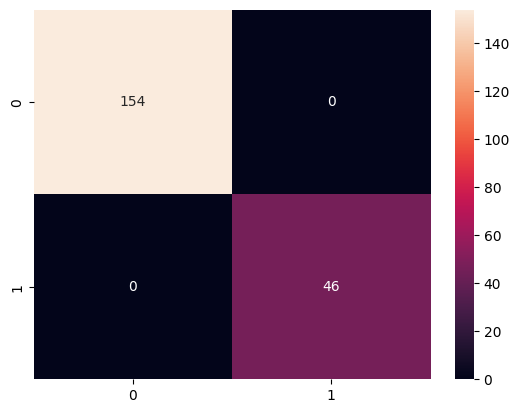

In [28]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.show

## Classification Report

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred_rf
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        46

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## Feature Importance

In [30]:
importance = rf.feature_importances_

In [35]:
feature_names= X.columns

In [36]:
importance_df = pd.DataFrame({

    "Feature":feature_names,
    "Importance":importance

})

In [38]:
importance_df.sort_values(
    by="Importance",
    ascending=False,
    inplace=True
)

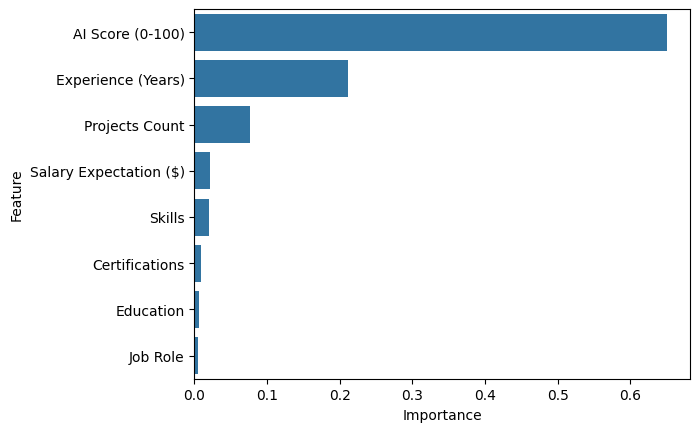

In [42]:
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.show()

## Save Model

In [47]:
import joblib 

joblib.dump(
    rf,
    "../model/model.pkl"
)

['../model/model.pkl']

## Prediction System

In [48]:
model = joblib.load(
    "../model/model.pkl"
)

In [46]:
sample = X.iloc[[0]]

prediction = model.predict(sample)

print(prediction)

[0]


# Conclusion

In this project, an AI-Based Hiring Prediction System was developed using Machine Learning techniques. The dataset was preprocessed, analyzed, and transformed to train multiple classification models. Different algorithms were evaluated, and the best-performing model was selected for predicting hiring decisions.

The final model can analyze candidate information such as skills, experience, education, certifications, projects, and salary expectations to predict whether a candidate is likely to be hired or rejected. This project demonstrates the practical application of Machine Learning in HR analytics and automated resume screening systems.